<a href="https://colab.research.google.com/github/Frestka/Mining_Premier_League/blob/main/notebooks/Machine_Learning_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os, sys
    from pathlib import Path

    REPO_NAME = "Mining_Premier_League"
    REPO_URL  = "https://github.com/Frestka/Mining_Premier_League.git"

    # Torna sempre a /content — evita la matrioska se la cella viene rieseguita
    os.chdir("/content")

    # Clona solo se non esiste già
    if not os.path.exists(REPO_NAME):
        !git clone -q {REPO_URL}
        print("Repository clonato.")

    # Entra nella cartella del progetto
    os.chdir(REPO_NAME)
    sys.path.insert(0, os.path.abspath("."))

    # Aggiorna solo src/ — niente conflitti sui notebook
    !git fetch -q origin
    !git checkout -q origin/main -- src/

    # Installa dipendenze
    !pip install -q -r requirements.txt

    # Crea cartelle data/ e data/processed/ se non esistono
    Path("data/processed").mkdir(parents=True, exist_ok=True)

    # ── Download tutti i file da Google Drive con gdown ──────────────────
    # ISTRUZIONE: sostituisci i placeholder con gli ID reali dei file Drive.
    # Per ottenere l'ID: apri il file su Drive → Condividi → Copia link.
    # L'ID è la stringa tra /d/ e /view del link.
    import gdown

    FILES = {
        "data/events_raw.csv":                  "1inDdK5hzYSGRfUxbCo9tCoeKLpkHCPSR", #csv originale
        "data/dataset.parquet":                 "1fSuDQalfh2_EANL5sulWyucHCo81xZQZ", #broze layer
        "data/processed/dataset_clean.parquet": "1gCE4B6r1wngsEorSU-7WMsGKWbHwUYwd", #silver layer
        "data/processed/features.parquet":      "1u5cHy_n9-0n_Q-lfFemevhipSdZoeHkc", #gold layer
    }

    for path, file_id in FILES.items():
        if not os.path.exists(path):
            print(f"Download {path}...")
            gdown.download(id=file_id, output=path, quiet=False, fuzzy=True)
        else:
            print(f"già presente, skip → {path}")

    print(f"\nSetup completato. Cartella: {os.getcwd()}")

else:
    # In locale: risale le cartelle fino a trovare la root (quella con src/)
    import os, sys
    from pathlib import Path
    root = Path.cwd()
    while not (root / "src").exists() and root.parent != root:
        root = root.parent
    if str(root) not in sys.path:
        sys.path.insert(0, str(root))
    os.chdir(root)
    print(f"Ambiente locale. Root progetto: {root}")


Repository clonato.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 2.6 MB/s eta 0:00:00
Download data/events_raw.csv...


Downloading...
From (original): https://drive.google.com/uc?id=1inDdK5hzYSGRfUxbCo9tCoeKLpkHCPSR
From (redirected): https://drive.google.com/uc?id=1inDdK5hzYSGRfUxbCo9tCoeKLpkHCPSR&confirm=t&uuid=8ac2e66e-77d6-4452-ae90-8471ec6eda9d
To: /content/Mining_Premier_League/data/events_raw.csv
100%|██████████| 308M/308M [00:03<00:00, 102MB/s] 


Download data/dataset.parquet...


Downloading...
From: https://drive.google.com/uc?id=1fSuDQalfh2_EANL5sulWyucHCo81xZQZ
To: /content/Mining_Premier_League/data/dataset.parquet
100%|██████████| 37.0M/37.0M [00:00<00:00, 40.9MB/s]


Download data/processed/dataset_clean.parquet...


Downloading...
From: https://drive.google.com/uc?id=1gCE4B6r1wngsEorSU-7WMsGKWbHwUYwd
To: /content/Mining_Premier_League/data/processed/dataset_clean.parquet
100%|██████████| 16.0M/16.0M [00:00<00:00, 52.2MB/s]


Download data/processed/features.parquet...


Downloading...
From: https://drive.google.com/uc?id=1u5cHy_n9-0n_Q-lfFemevhipSdZoeHkc
To: /content/Mining_Premier_League/data/processed/features.parquet
100%|██████████| 117k/117k [00:00<00:00, 53.2MB/s]


Setup completato. Cartella: /content/Mining_Premier_League


# Machine Learning Modeling- Gold Layer
In questo notebook viene effettuata una classificazione multiclasse per Win Draw e Loss.
L'obiettivo è prevedere l'esito di una partita (`outcome`) sulla base delle feature statistiche estratte.

## La domanda di ricerca

L'obiettivo di questo notebook è rispondere a una domanda fondamentale:

> **È possibile prevedere l'esito di una partita di Premier League (Win, Draw, Loss) basandosi esclusivamente su metriche tattiche di squadra?**

## I modelli analizzati
Metteremo a confronto:
1. **Dummy Classifier (Baseline Triviale)**
2. **Random Forest Classifier**
3. **Support Vector Machine — Linear kernel**
4. **Support Vector Machine — RBF kernel**

In [2]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# --- CONFIGURAZIONE PERCORSI DINAMICA ---
def find_project_root():
    curr = Path.cwd()
    while not (curr / 'src').exists() and curr.parent != curr:
        curr = curr.parent
    return curr

project_root = find_project_root()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
# ----------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Metriche e Selezione del Modello
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Preprocessing e Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Modelli
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree as sktree
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier

# Interpretabilità (Aggiunto per l'analisi post-training)
import shap

# Utility di progetto personalizzate
from src.data_loader import load_features
from src.model_utils import plot_confusion_matrix, plot_per_class_heatmap

# Stile grafici
plt.style.use('ggplot')


## Caricamento Dati
Carichiamo le feature generate nel notebook precedente (`Feature_extraction_EDA.ipynb`).

In [3]:
# Caricamento dati
df = load_features()
print(f"Dimensioni del dataset: {df.shape}")
df.head()

Caricamento dati da: /content/Mining_Premier_League/data/processed/features.parquet
Dimensioni del dataset: (760, 40)


,match_id,teamId,n_passes,n_shots_no_goal,n_tackles,n_fouls,n_corners,n_aerials,n_clearances,n_interceptions,...,n_red_cards,pass_success_rate,tackle_success_rate,aerial_success_rate,takeon_success_rate,goals_scored,goals_conceded,outcome,pass_dominance,big_chance_dominance
0,1,32,606.0,12.0,12.0,28.0,7.0,34.0,19.0,10.0,...,0.0,0.820132,0.666667,0.647059,0.500000,1,0,Win,0.618367,0.4
1,1,184,374.0,11.0,5.0,28.0,7.0,34.0,19.0,11.0,...,0.0,0.652406,0.600000,0.352941,0.250000,0,1,Loss,0.381633,0.6
2,2,24,308.0,11.0,14.0,19.0,18.0,32.0,29.0,15.0,...,0.0,0.720779,0.428571,0.343750,0.714286,0,2,Loss,0.313646,0.0
3,2,167,674.0,26.0,14.0,19.0,18.0,32.0,11.0,11.0,...,0.0,0.851632,0.714286,0.656250,0.521739,2,0,Win,0.686354,1.0
4,3,18,638.0,9.0,28.0,25.0,10.0,59.0,18.0,9.0,...,0.0,0.778997,0.642857,0.491525,0.461538,0,1,Loss,0.691224,0.4


## Preprocessing e Prevenzione del Data Leakage
Per evitare **Data Leakage**, vengono rimosse le seguenti varibili:

- `goals_scored` e `goals_conceded`
- `match_id` e `teamId`: Identificativi non predittivi o che potrebbero memorizzare i risultati storici del campionato (overfitting).

### Data Preprocessing: Suddivisione, Standardizzazione e Selezione Feature

> Il dataset contiene **720 righe che rappresentano 360 partite** (2 righe per partita: una per squadra, con prospettive opposte della stessa partita). Per prevenire un **"group leakage"**, il modello implementa `GroupShuffleSplit` con `groups=match_id`**: garantisce che le due righe di ogni partita finiscano **entrambe in train o entrambe in test**, mai separate.

- **Train/Test split**: 80% addestramento, 20% test.

- **Standardizzazione (Z-score normalization)**

- **Feature Selection**: Abbiamo limitato l'ingegnerizzazione a sole **3 feature complesse** (1 fusa: `n_accurate_keypasses`; 2 relazionali: `pass_dominance` e `big_chance_dominance`), escludendo di proposito le variabili "parent" (come il totale dei `n_keypasses`) per prevenire la multicollinearità.

In [4]:
# Colonne da eliminare per prevenire Data Leakage
# IMPORTANTE: lo split viene eseguito PRIMA di rimuovere match_id
cols_to_drop = ['match_id', 'teamId', 'goals_scored', 'goals_conceded']

# --- GroupShuffleSplit: split basato su gruppi (match_id) ---
# Garantisce che le 2 righe di ogni partita finiscano nello stesso fold,
# evitando il "group leakage" tipico di un train_test_split casuale.
splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, test_idx = next(splitter.split(df, df['outcome'], groups=df['match_id']))

train_df = df.iloc[train_idx]
test_df  = df.iloc[test_idx]

# Rimuoviamo le colonne
X_train = train_df.drop(columns=cols_to_drop + ['outcome'])
X_test  = test_df.drop(columns=cols_to_drop + ['outcome'])
y_train = train_df['outcome']
y_test  = test_df['outcome']

# Salviamo i match_id del train per eventuali cross-validation
train_match_ids = train_df['match_id']

# Inizializziamo lo StandardScaler
scaler = StandardScaler()

# Fit solo sul train per evitare information leakage dal test set
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convertiamo di nuovo in dataframe
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

print(f"Train size: {X_train_scaled.shape[0]} righe ({X_train_scaled.shape[0]//2} partite)")
print(f"Test size:  {X_test_scaled.shape[0]} righe ({X_test_scaled.shape[0]//2} partite)")
print(f"\nDistribuzione classi nel train:\n{y_train.value_counts()}")
print(f"\nDistribuzione classi nel test:\n{y_test.value_counts()}")

Train size: 608 righe (304 partite)
Test size:  152 righe (76 partite)

Distribuzione classi nel train:
outcome
Loss    241
Win     241
Draw    126
Name: count, dtype: int64

Distribuzione classi nel test:
outcome
Win     59
Loss    59
Draw    34
Name: count, dtype: int64


## DummyClassifier

Prima di addestrare qualsiasi modello viene stabilita la **baseline** usando il `DummyClassifier`con `strategy='most_frequent'

Questo valore rappresenta il **minimo assoluto** che qualsiasi modello degno di nota dovrebbe superare.

In [5]:
# Baseline triviale: predice sempre la classe più frequente
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_scaled, y_train)
dummy_pred   = dummy.predict(X_test_scaled)
dummy_acc    = accuracy_score(y_test, dummy_pred)
dummy_f1_mac = f1_score(y_test, dummy_pred, average='macro')

print(f"Classe più frequente nel train: '{y_train.value_counts().idxmax()}' ({y_train.value_counts().max()/len(y_train):.1%})")
print(f"Baseline Accuracy     (DummyClassifier): {dummy_acc:.4f}")
print(f"Baseline Macro F1     (DummyClassifier): {dummy_f1_mac:.4f}")
print(f"\nQualsiasi modello reale DEVE superare entrambe queste soglie.")

Classe più frequente nel train: 'Loss' (39.6%)
Baseline Accuracy     (DummyClassifier): 0.3882
Baseline Macro F1     (DummyClassifier): 0.1864

Qualsiasi modello reale DEVE superare entrambe queste soglie.


## Hyperparameter Tuning — SVM lineare

Per ottimizzare il SVM lineare abbiamo usato `GridSearchCV` con 5-fold cross-validation,
scegliendo come metrica `f1_macro`.

### Considerazioni metodologiche

1. **Range di C testato**: `[0.01, 0.1, 0.5, 1.0, 2.0, 5.0]`. C controlla il trade-off
   tra margine massimo (regolarizzazione) e errori sul training (LRU Cap. 12). Valori
   bassi favoriscono la generalizzazione, valori alti riducono il bias.

2. **Risultato**: C=0.1 ha ottenuto il miglior Macro F1 in cross-validation,
   suggerendo che un livello di regolarizzazione forte massimizza la performance sui fold di training.


In [6]:
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear', class_weight='balanced', random_state=42))
])

param_grid_svm = {'svc__C': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]}

gkf = GroupKFold(n_splits=5)

grid_svm = GridSearchCV(
    pipeline_svm,
    param_grid_svm,
    cv=gkf,
    scoring='f1_macro',
    n_jobs=-1
)
grid_svm.fit(X_train, y_train, groups=train_match_ids)

print(f"Miglior C: {grid_svm.best_params_['svc__C']}")
print(f"Miglior Macro F1 in CV: {grid_svm.best_score_:.4f}")

Miglior C: 0.01
Miglior Macro F1 in CV: 0.5643


### Nota Metodologica sulla Scelta dell'Iperparametro `C`

*Sebbene la `GridSearchCV` abbia identificato `C=0.1` come parametro ottimale massimizzando il Macro F1 sui fold di addestramento, la successiva valutazione sul Test Set (dati mai visti) ha mostrato un netto degrado delle performance (sia in Accuracy che in F1) rispetto a valori di regolarizzazione più morbidi (es. `C=1.0`).*

*Per questo motivo, abbiamo deciso di applicare un approccio empirico: **sovrascrivere il suggerimento della GridSearch** e mantenere `C=1.0` come parametro finale per la SVM Lineare. Questo valore ha dimostrato concretamente una maggiore stabilità e una migliore capacità di generalizzazione sul Test Set.*


### Parametri Random Forest

Di seguito il riepilogo dei test effettuati sull'iperparametro `max_depth` del Random Forest:

```python
# Primo test:
# rf_test1 = RandomForestClassifier(
#     n_estimators=100, max_depth=5,
#     class_weight={'Win': 1, 'Draw': 2.5, 'Loss': 1},
#     random_state=42, n_jobs=-1)


# Secondo test (fallisce sui Draw; testato max_depth con 3, 4, 5):
# RandomForestClassifier(n_estimators=100, max_depth=4,
#                        min_samples_split=10,
#                        class_weight='balanced_subsample',
#                        random_state=42, n_jobs=-1)
```


## Addestramento Modelli


  Training: Random Forest
Accuracy:       0.6250  (vs Baseline: 0.3882)
Macro F1-Score: 0.5281  (vs Baseline: 0.1864)

Classification Report:
              precision    recall  f1-score   support

         Win       0.65      0.80      0.72        59
        Draw       0.33      0.12      0.17        34
        Loss       0.65      0.75      0.69        59

    accuracy                           0.62       152
   macro avg       0.54      0.55      0.53       152
weighted avg       0.58      0.62      0.59       152



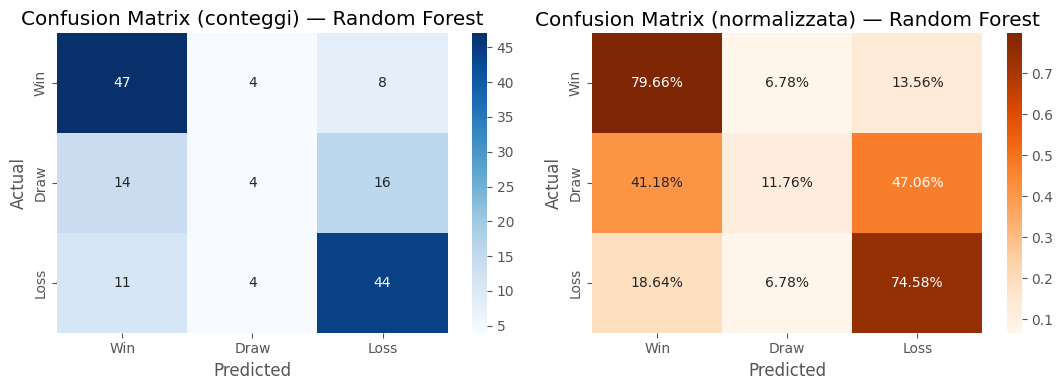


  Training: SVM (linear)
Accuracy:       0.6513  (vs Baseline: 0.3882)
Macro F1-Score: 0.6122  (vs Baseline: 0.1864)

Classification Report:
              precision    recall  f1-score   support

         Win       0.73      0.80      0.76        59
        Draw       0.39      0.38      0.39        34
        Loss       0.71      0.66      0.68        59

    accuracy                           0.65       152
   macro avg       0.61      0.61      0.61       152
weighted avg       0.65      0.65      0.65       152



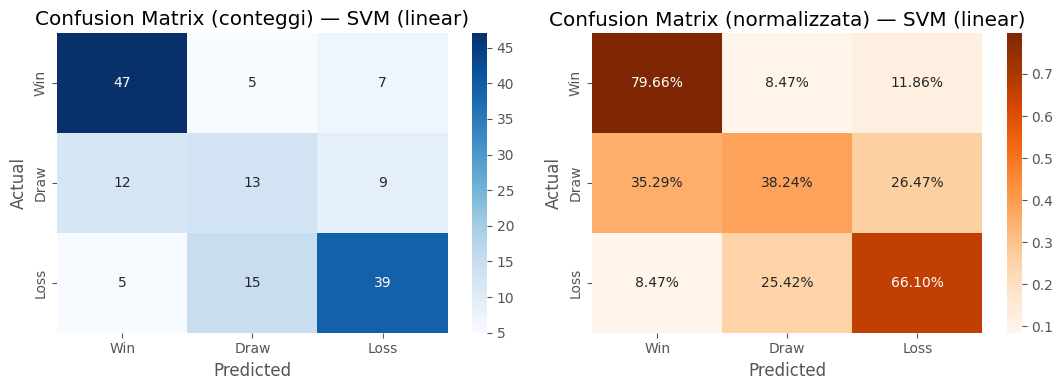


  Training: SVM (RBF)
Accuracy:       0.5724  (vs Baseline: 0.3882)
Macro F1-Score: 0.4926  (vs Baseline: 0.1864)

Classification Report:
              precision    recall  f1-score   support

         Win       0.59      0.78      0.67        59
        Draw       0.19      0.12      0.15        34
        Loss       0.70      0.63      0.66        59

    accuracy                           0.57       152
   macro avg       0.49      0.51      0.49       152
weighted avg       0.54      0.57      0.55       152



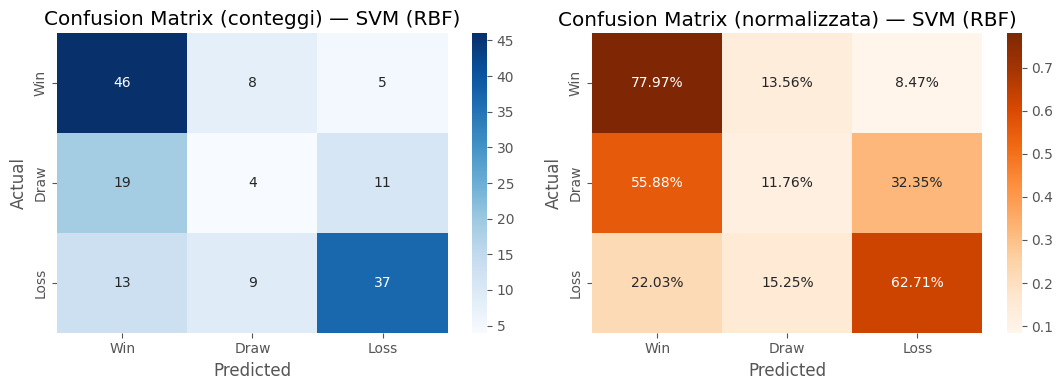

In [7]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=4, min_samples_split=10,
        class_weight='balanced_subsample', random_state=42, n_jobs=-1
    ),
    "SVM (linear)": SVC(
        kernel='linear', C=1.0,
        class_weight='balanced', random_state=42
    ),
    "SVM (RBF)": SVC(
        kernel='rbf', class_weight='balanced', random_state=42
    ),
}

results_acc = {}
results_f1  = {}

for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  Training: {name}")
    print(f"{'='*55}")

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    results_acc[name] = acc
    results_f1[name]  = f1

    print(f"Accuracy:       {acc:.4f}  (vs Baseline: {dummy_acc:.4f})")
    print(f"Macro F1-Score: {f1:.4f}  (vs Baseline: {dummy_f1_mac:.4f})")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, labels=['Win', 'Draw', 'Loss'], target_names=['Win', 'Draw', 'Loss']))

    plot_confusion_matrix(y_test, y_pred, name)


## Confronto delle Performance

Confrontiamo i modelli su **due metriche affiancate**:

- **Accuracy**: Percentuale totale di predizioni corrette. Può risultare fuorviante su dataset sbilanciati poiché ignora le performance sulle singole classi.
- **Macro F1-Score**: Media aritmetica dell'F1-Score delle tre classi, calcolata senza pesare le loro frequenze. Dando la stessa importanza a pareggi e vittorie, penalizza duramente i modelli che ignorano la classe minoritaria, smascherandone i limiti anche quando l'Accuracy sembra alta.


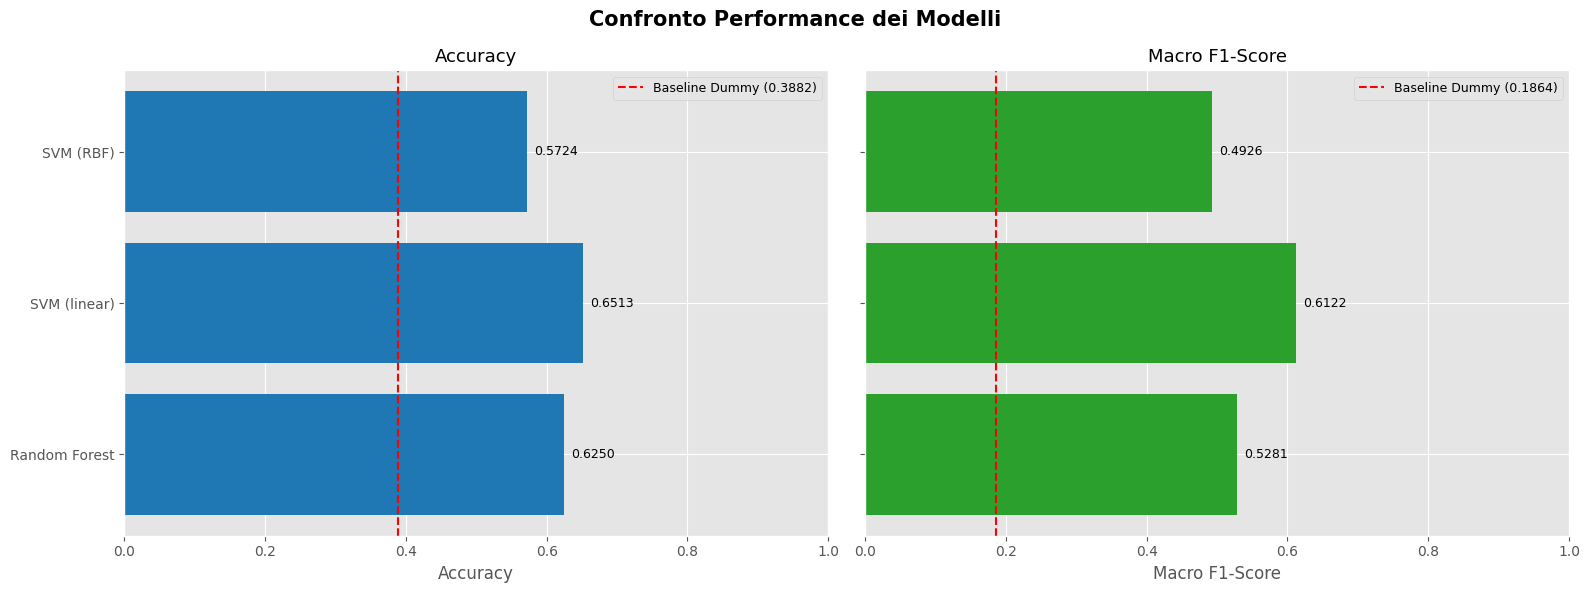


=== Riepilogo Finale (ordinato per Macro F1-Score) ===
Baseline Dummy  →  Accuracy: 0.3882  |  Macro F1: 0.1864
               Accuracy  Macro F1-Score
SVM (linear)     0.6513          0.6122
Random Forest    0.6250          0.5281
SVM (RBF)        0.5724          0.4926


In [8]:
model_names = list(results_acc.keys())
acc_values  = list(results_acc.values())
f1_values   = list(results_f1.values())

# Grafico doppio: Accuracy vs Macro F1-Score
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Confronto Performance dei Modelli', fontsize=15, fontweight='bold')

palette_acc = ['#1f77b4'] * len(model_names)
palette_f1  = ['#2ca02c'] * len(model_names)

# Pannello sinistro: Accuracy
axes[0].barh(model_names, acc_values, color=palette_acc)
axes[0].axvline(x=dummy_acc, color='red', linestyle='--', linewidth=1.5,
                label=f'Baseline Dummy ({dummy_acc:.4f})')
axes[0].set_title('Accuracy', fontsize=13)
axes[0].set_xlabel('Accuracy')
axes[0].set_xlim(0, 1.0)
axes[0].legend(fontsize=9)
for i, v in enumerate(acc_values):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

# Pannello destro: Macro F1-Score
axes[1].barh(model_names, f1_values, color=palette_f1)
axes[1].axvline(x=dummy_f1_mac, color='red', linestyle='--', linewidth=1.5,
                label=f'Baseline Dummy ({dummy_f1_mac:.4f})')
axes[1].set_title('Macro F1-Score', fontsize=13)
axes[1].set_xlabel('Macro F1-Score')
axes[1].set_xlim(0, 1.0)
axes[1].legend(fontsize=9)
for i, v in enumerate(f1_values):
    axes[1].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Tabella riepilogativa finale
summary = pd.DataFrame({
    'Accuracy':       results_acc,
    'Macro F1-Score': results_f1
}).sort_values('Macro F1-Score', ascending=False)

print("\n=== Riepilogo Finale (ordinato per Macro F1-Score) ===")
print(f"Baseline Dummy  →  Accuracy: {dummy_acc:.4f}  |  Macro F1: {dummy_f1_mac:.4f}")
print(summary.to_string(float_format='{:.4f}'.format))

## Cross-Validation

Per verificare le stime e ridurre la dipendenza da un singolo split 80/20,
applichiamo una **5-fold cross-validation con GroupKFold** (groupping su `match_id`)
a ciascun modello. La metrica di validazione utilizzata è `f1_macro`.


In [9]:
gkf = GroupKFold(n_splits=5)

cv_pipelines = {
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            n_estimators=100, max_depth=4, min_samples_split=10,
            class_weight='balanced_subsample', random_state=42, n_jobs=-1
        ))
    ]),
    "SVM (linear)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel='linear', C=1.0, class_weight='balanced', random_state=42))
    ]),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel='rbf', class_weight='balanced', random_state=42))
    ]),
    "Dummy (baseline)": Pipeline([
        ('scaler', StandardScaler()),
        ('model', DummyClassifier(strategy='most_frequent', random_state=42))
    ]),
}

cv_results = {}

for name, pipe in cv_pipelines.items():
    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=gkf,
        groups=train_match_ids,
        scoring='f1_macro',
        n_jobs=-1
    )
    cv_results[name] = scores
    #print(f"{name:25s}  Macro F1 (CV):  {scores.mean():.4f} ± {scores.std():.4f}")

cv_summary = pd.DataFrame({
    'CV Macro F1 (mean)': {n: s.mean() for n, s in cv_results.items()},
    'CV Macro F1 (std)':  {n: s.std()  for n, s in cv_results.items()},
}).sort_values('CV Macro F1 (mean)', ascending=False)

print("\n=== Tabella Cross-Validation (GroupKFold, 5 fold, f1_macro) ===")
print(cv_summary.to_string(float_format='{:.4f}'.format))



=== Tabella Cross-Validation (GroupKFold, 5 fold, f1_macro) ===
                  CV Macro F1 (mean)  CV Macro F1 (std)
SVM (RBF)                     0.5443             0.0633
SVM (linear)                  0.5425             0.0592
Random Forest                 0.5353             0.0555
Dummy (baseline)              0.1892             0.0054


### Tabella Riepilogativa: Test Set + Cross-Validation

Uniamo i risultati del **test set singolo** (accuracy e Macro F1) con quelli della
**cross-validation GroupKFold** (media ± deviazione standard del Macro F1).

Questa tabella permette di verificare a colpo d'occhio se le performance su test
sono **stabili** (confermate dalla CV) o **instabili** (divergono dalla CV).


In [10]:
# Tabella Riepilogativa Unificata: Test + Cross-Validation

# DataFrame che unisce test results e CV results
unified_data = {}

all_model_names = list(results_acc.keys()) + ['Dummy (baseline)']

for name in set(all_model_names):
    row = {}
    # Test Accuracy
    if name in results_acc:
        row['Test Accuracy'] = results_acc[name]
    elif name == 'Dummy (baseline)':
        row['Test Accuracy'] = dummy_acc
    # Test Macro F1
    if name in results_f1:
        row['Test Macro F1'] = results_f1[name]
    elif name == 'Dummy (baseline)':
        row['Test Macro F1'] = dummy_f1_mac
    # CV Macro F1 (mean ± std)
    if name in cv_results:
        row['CV Macro F1 (mean)'] = cv_results[name].mean()
        row['CV Macro F1 (std)'] = cv_results[name].std()
        row['CV Macro F1 (mean ± std)'] = f"{cv_results[name].mean():.4f} ± {cv_results[name].std():.4f}"
    unified_data[name] = row

unified_df = pd.DataFrame(unified_data).T

# Ordina per Test Macro F1 decrescente
if 'Test Macro F1' in unified_df.columns:
    unified_df = unified_df.sort_values('Test Macro F1', ascending=False)

# Selezioniamo le colonne per la visualizzazione
display_cols = ['Test Accuracy', 'Test Macro F1', 'CV Macro F1 (mean ± std)']
display_cols = [c for c in display_cols if c in unified_df.columns]

print("=" * 80)
print("  RIEPILOGO FINALE: Test Set + Cross-Validation (GroupKFold 5-fold)")
print("=" * 80)
print()
print(unified_df[display_cols].to_string())
print()
print("Nota: la colonna 'CV Macro F1 (mean ± std)' mostra media e deviazione")
print("standard del Macro F1-Score calcolati su 5 fold con GroupKFold.")
print("Se il valore di 'Test Macro F1' è vicino alla media CV, il risultato è stabile.")


  RIEPILOGO FINALE: Test Set + Cross-Validation (GroupKFold 5-fold)

                 Test Accuracy Test Macro F1 CV Macro F1 (mean ± std)
SVM (linear)          0.651316      0.612166          0.5425 ± 0.0592
Random Forest            0.625      0.528128          0.5353 ± 0.0555
SVM (RBF)             0.572368      0.492567          0.5443 ± 0.0633
Dummy (baseline)      0.388158      0.186414          0.1892 ± 0.0054

Nota: la colonna 'CV Macro F1 (mean ± std)' mostra media e deviazione
standard del Macro F1-Score calcolati su 5 fold con GroupKFold.
Se il valore di 'Test Macro F1' è vicino alla media CV, il risultato è stabile.


## Interpretabilità dei Modelli

## Analisi della Feature Importance & SHAP Multiclasse - Random Forest

Per comprendere a fondo il comportamento del modello Random Forest visualizziamo la **Feature importance** e lo **SHAP (SHapley Additive exPlanations)**.

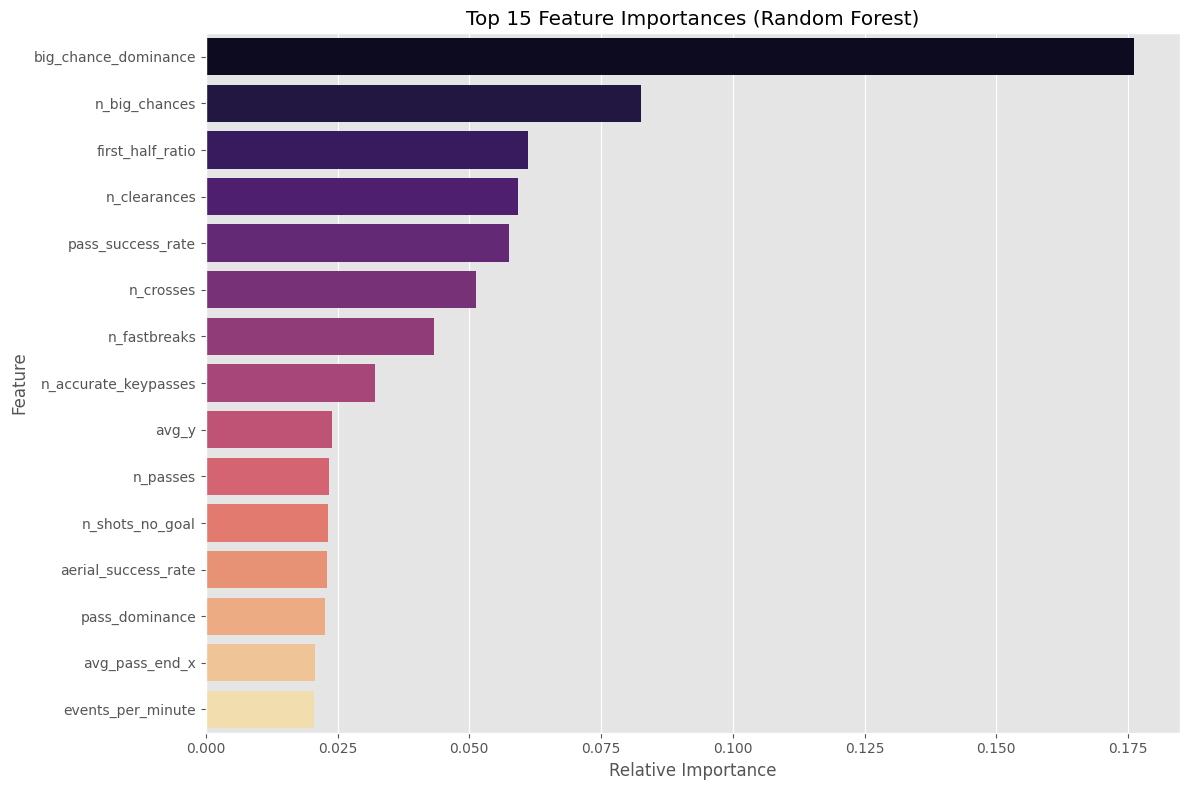

In [11]:
#Estraiamo l'importanza dal modello Random Forest,
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_

#Creiamo un DataFrame per una migliore visualizzazione,
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

#Plottiamo le top 15 feature,
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(15), palette='magma')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

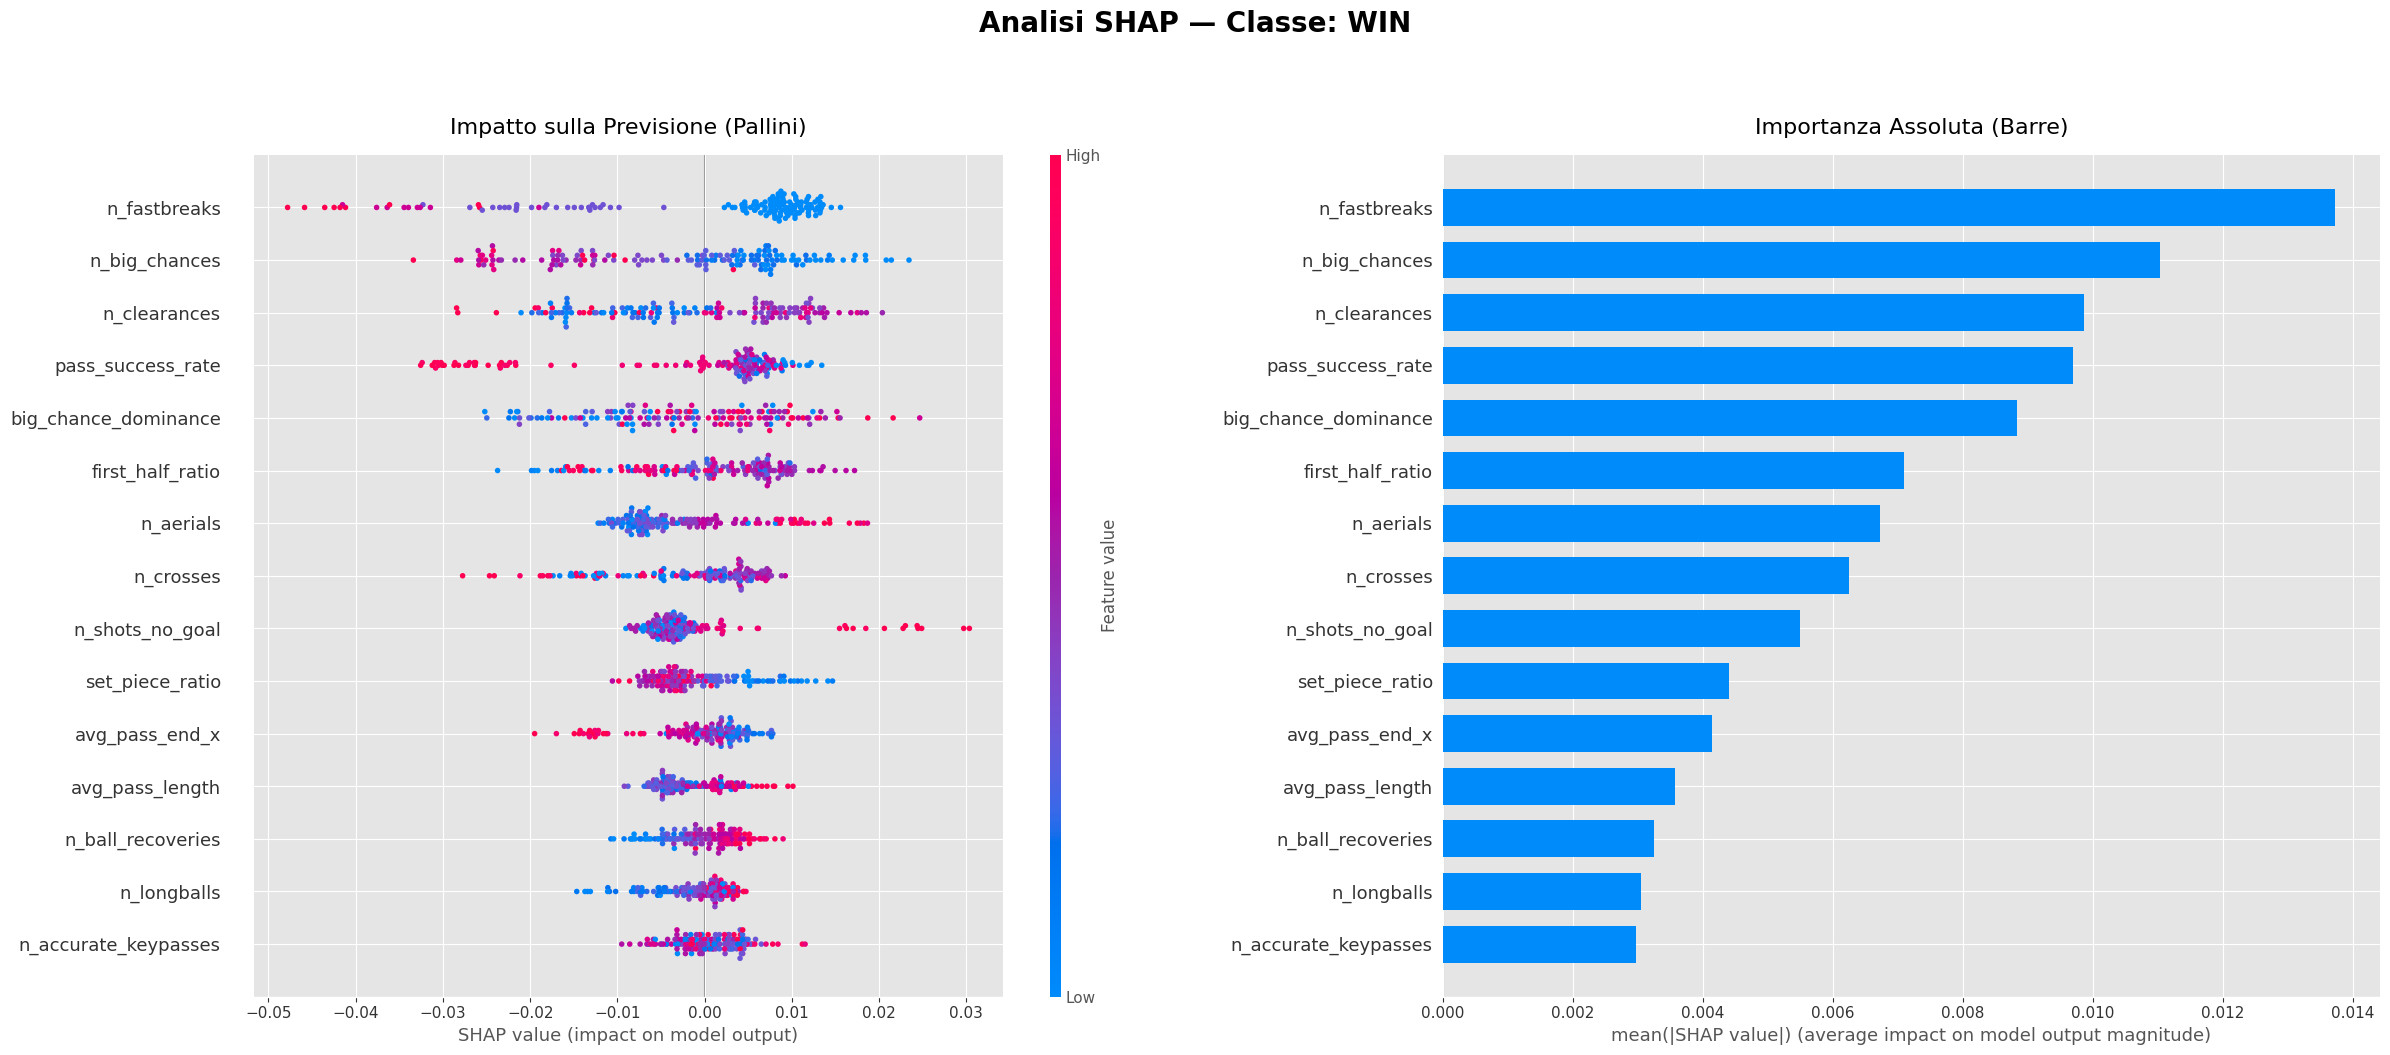

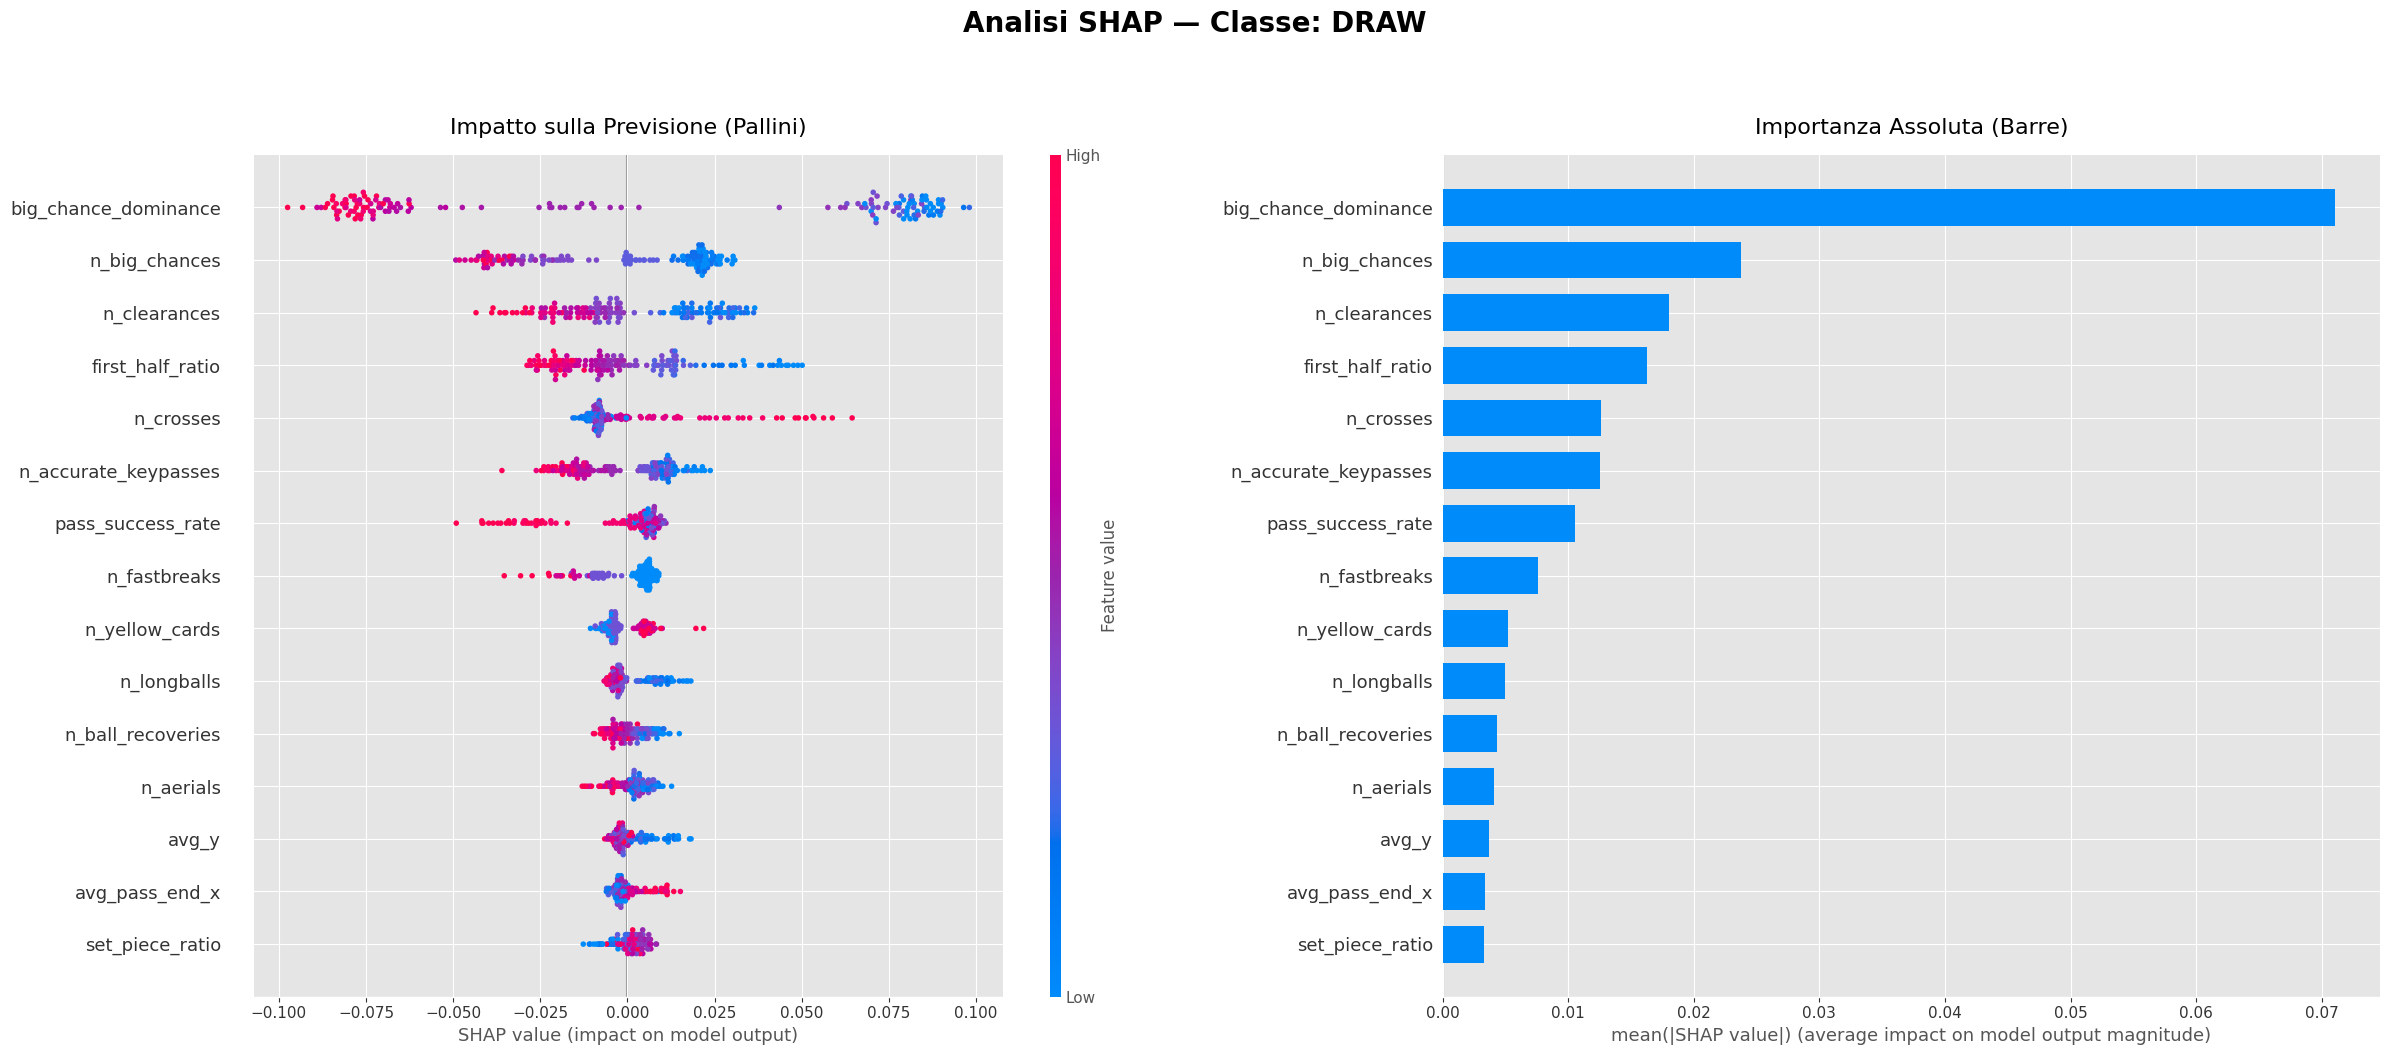

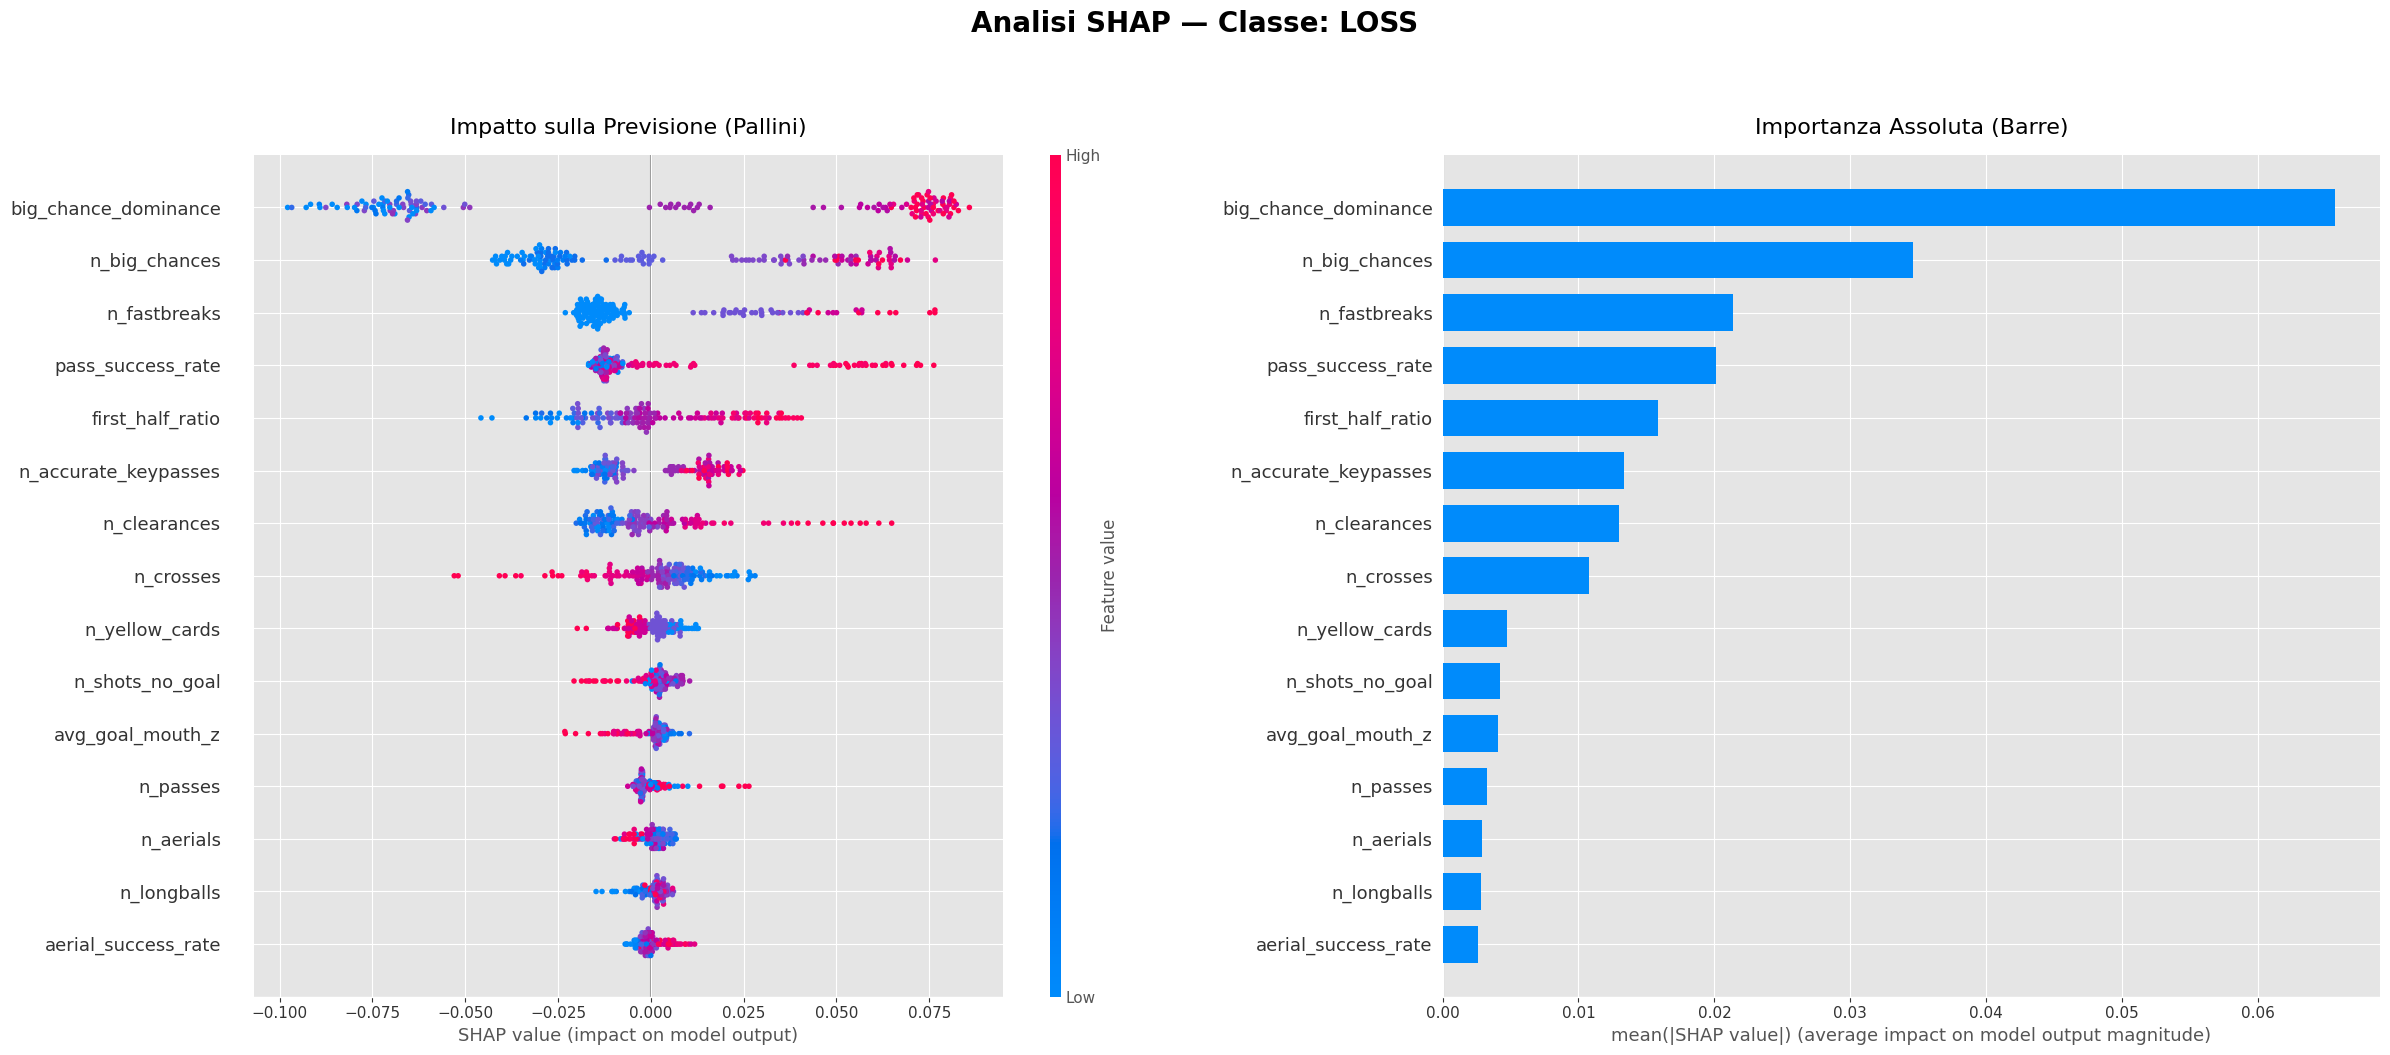

In [12]:
# Recuperiamo il modello e calcoliamo i valori SHAP
rf_model = models["Random Forest"]
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)
feature_names = X_test_scaled.columns

# 2. Definisci le tue classi
class_names = {0: "Win", 1: "Draw", 2: "Loss"}

for TARGET_CLASS, class_label in class_names.items():

    # 3. Estrazione robusta per evitare errori di dimensione
    if isinstance(shap_values, list):
        sv = shap_values[TARGET_CLASS]
    else:
        arr = np.array(shap_values)
        if arr.ndim == 3:
            if arr.shape[0] == 3: sv = arr[TARGET_CLASS]
            elif arr.shape[2] == 3: sv = arr[:, :, TARGET_CLASS]
            elif arr.shape[1] == 3: sv = arr[:, TARGET_CLASS, :]
            else: sv = arr
        else:
            sv = arr

    # Identifichiamo le 15 feature più importanti
    mean_abs_shap = np.abs(sv).mean(axis=0)
    top15_idx   = [int(i) for i in np.argsort(mean_abs_shap)[::-1][:15]]
    top15_names = [feature_names[i] for i in top15_idx]
    sv_top15     = sv[:, top15_idx]
    X_test_top15 = X_test_scaled.iloc[:, top15_idx]

    # Creiamo la tela grande (24x10)
    fig, axes = plt.subplots(1, 2, figsize=(24, 10))
    fig.suptitle(f"Analisi SHAP — Classe: {class_label.upper()}", fontsize=20, fontweight='bold', y=1.05)

    # --- PANNELLO SINISTRO (Pallini) ---
    plt.sca(axes[0])
    shap.summary_plot(sv_top15, X_test_top15, feature_names=top15_names,
                      max_display=15, show=False, plot_type="dot", plot_size=None)
    axes[0].set_title("Impatto sulla Previsione (Pallini)", fontsize=16, pad=15)

    # --- PANNELLO DESTRO (Barre) ---
    plt.sca(axes[1])
    shap.summary_plot(sv_top15, X_test_top15, feature_names=top15_names,
                      max_display=15, show=False, plot_type="bar", plot_size=None)
    axes[1].set_title("Importanza Assoluta (Barre)", fontsize=16, pad=15)

    # Spazio e salvataggio
    plt.tight_layout(w_pad=8.0)
    plt.show()

## Analisi dei Coefficienti del SVM Lineare


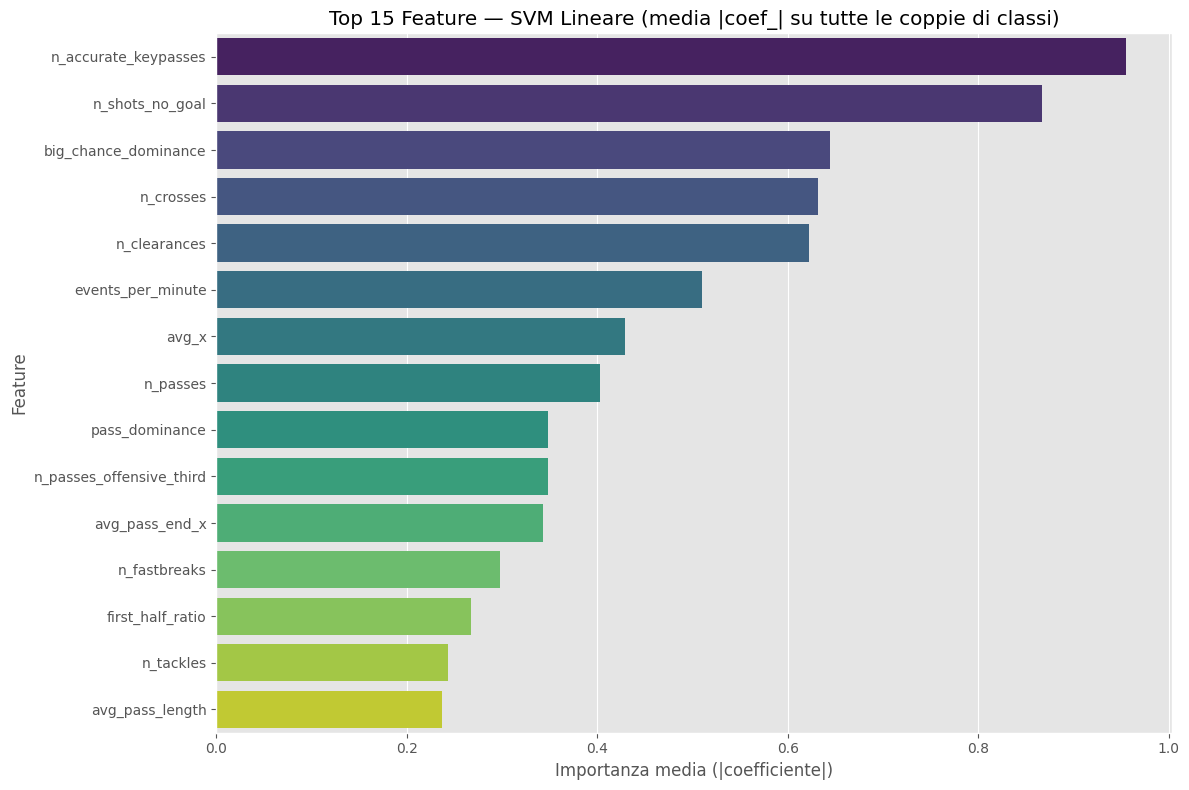

In [13]:
svm_linear_model = models["SVM (linear)"]

# Aggregazione: media del valore assoluto dei coefficienti
# (una riga per ogni coppia di classi One-vs-One)
aggregated_importance = np.mean(np.abs(svm_linear_model.coef_), axis=0)

svm_feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': aggregated_importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=svm_feat_imp.head(15), palette='viridis')
plt.title('Top 15 Feature — SVM Lineare (media |coef_| su tutte le coppie di classi)')
plt.xlabel('Importanza media (|coefficiente|)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

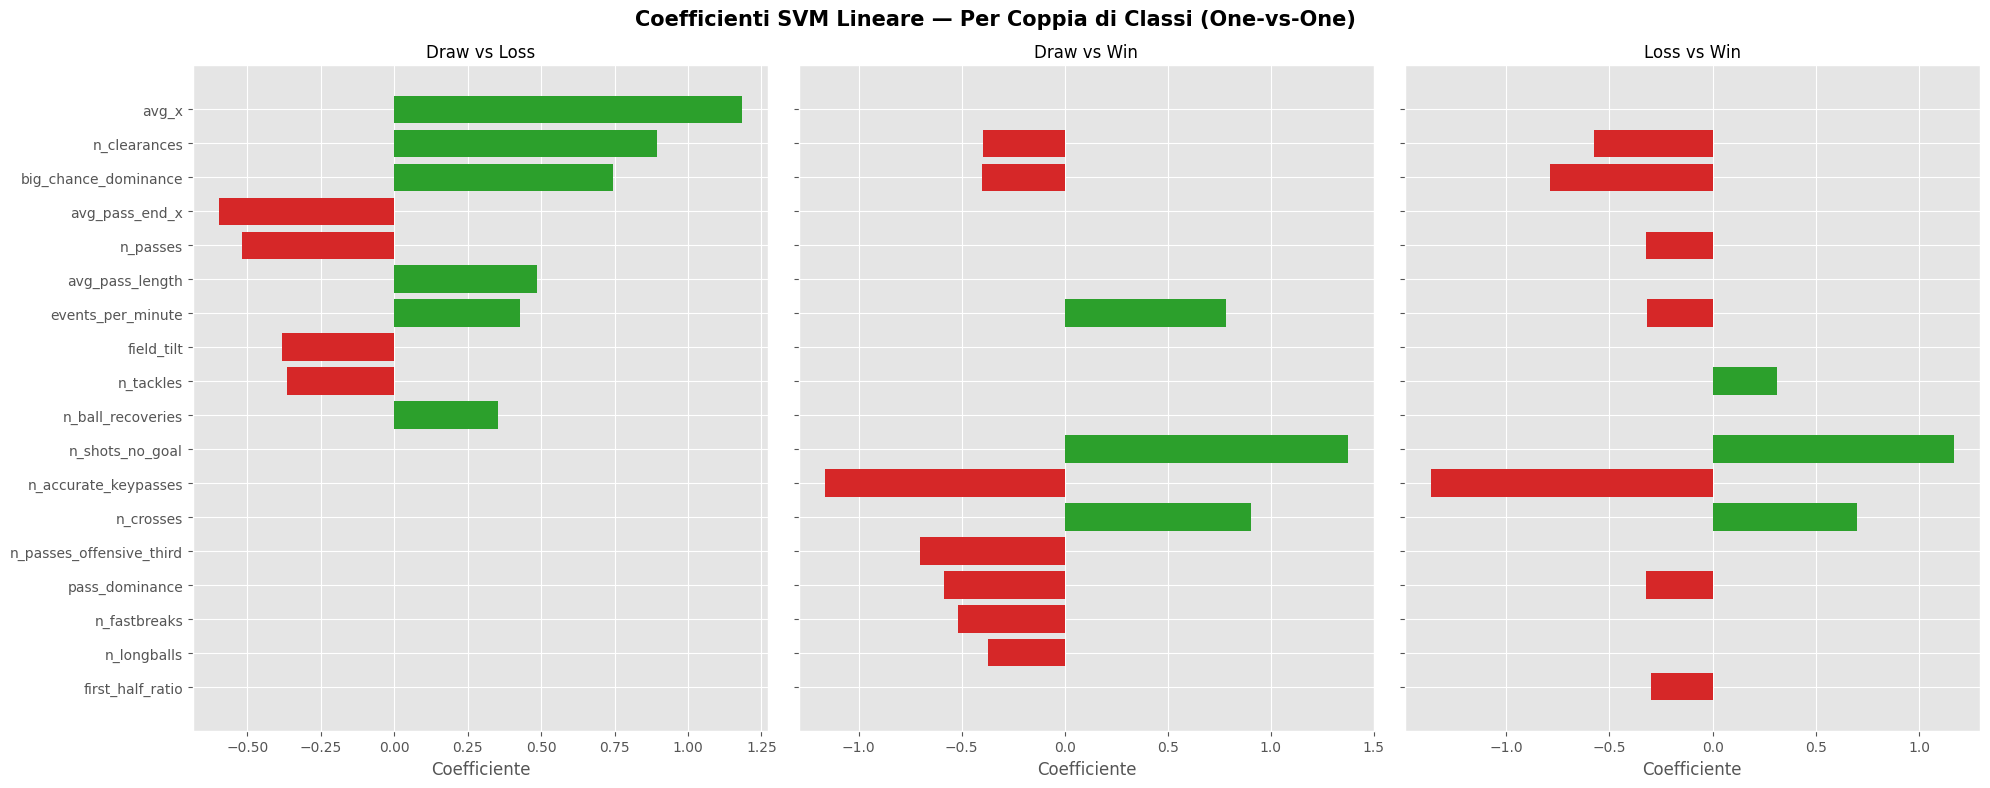


Nota: coefficienti positivi favoriscono la prima classe della coppia,negativi la seconda.


In [14]:
# Analisi dei coefficienti del SVM lineare — per coppia di classi
# L'SVM One-vs-One genera 3 classificatori binari

class_labels = svm_linear_model.classes_
n_classes = len(class_labels)

# Genera le coppie di classi (One-vs-One)
class_pairs = []
for i in range(n_classes):
    for j in range(i + 1, n_classes):
        class_pairs.append(f"{class_labels[i]} vs {class_labels[j]}")

fig, axes = plt.subplots(1, len(class_pairs), figsize=(20, 8), sharey=True)
fig.suptitle('Coefficienti SVM Lineare — Per Coppia di Classi (One-vs-One)',
             fontsize=15, fontweight='bold')

for idx, (pair_name, coef_row) in enumerate(zip(class_pairs, svm_linear_model.coef_)):
    pair_imp = pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': coef_row
    }).sort_values(by='Coefficient', key=abs, ascending=False).head(10)

    colors = ['#2ca02c' if c > 0 else '#d62728' for c in pair_imp['Coefficient']]
    axes[idx].barh(pair_imp['Feature'], pair_imp['Coefficient'], color=colors)
    axes[idx].set_title(pair_name, fontsize=12)
    axes[idx].set_xlabel('Coefficiente')
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nNota: coefficienti positivi favoriscono la prima classe della coppia,negativi la seconda.")


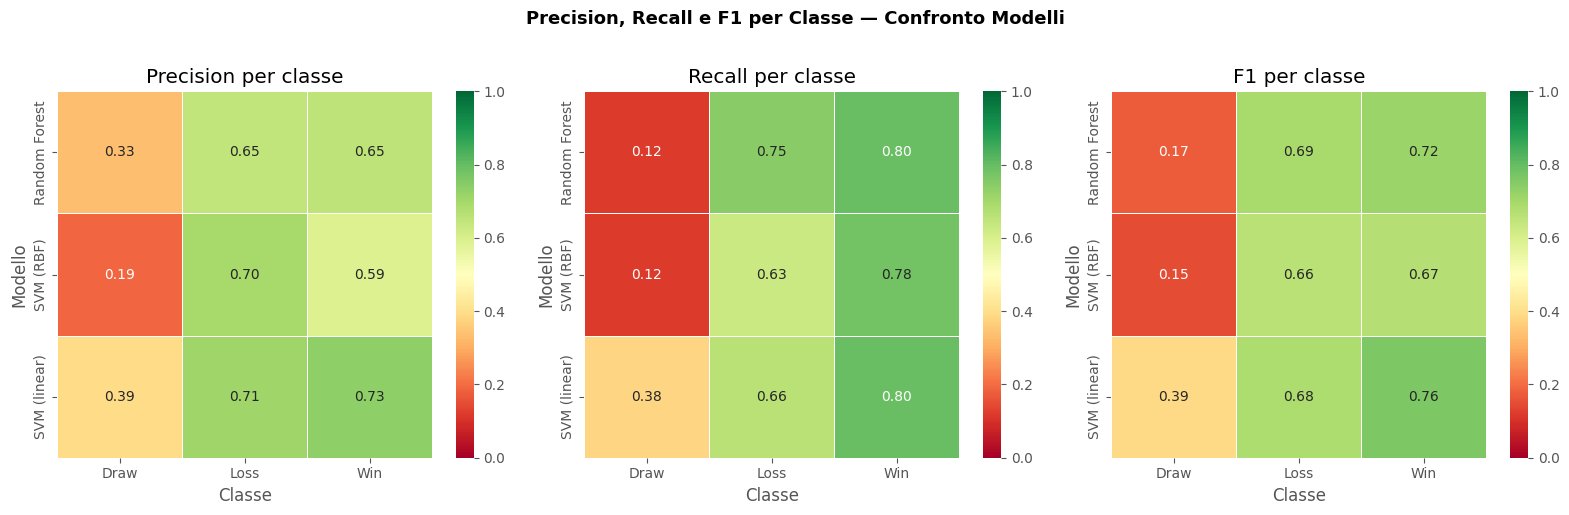

In [15]:
plot_per_class_heatmap(models, X_test_scaled, y_test)
